# import library

In [98]:
#General Libraries
import numpy as np                    # For numerical computations
import pandas as pd                   # For handling dataframes

# Data Visualization
import matplotlib.pyplot as plt        # For plotting graphs
import seaborn as sns                 # For advanced plots
from matplotlib.pyplot import figure

# Preprocessing
from sklearn.preprocessing import StandardScaler,PolynomialFeatures,LabelEncoder # For feature scaling
from sklearn.model_selection import train_test_split , GridSearchCV # For splitting the dataset

# Regression Models
from sklearn.linear_model import LinearRegression      # Model 1: Linear Regression
from sklearn.tree import DecisionTreeRegressor         # Model 2: Decision Tree Regression
from sklearn.ensemble import RandomForestRegressor     # Model 3: Random Forest Regression
from sklearn.svm import SVR

# Classification Models
from sklearn.linear_model import LogisticRegression     # Model 1: Logistic Regression (Classification)
from sklearn.tree import DecisionTreeClassifier         # Model 2: Decision Tree Classifier
from sklearn.ensemble import RandomForestClassifier     # Model 3: Random Forest Classifier
from sklearn.neighbors import KNeighborsClassifier      # Model 4: kNeighbors Classifier
from sklearn.svm import SVC                             # Model 5: Support vector machine
from sklearn.naive_bayes import GaussianNB

# Evaluation Metrics - Regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from imblearn.under_sampling import RandomUnderSampler

# Evaluation Metrics - Classification
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Load the Data

In [99]:
# تحميل البيانات
data = pd.read_csv(r'archive 22/loan_data.csv')
data

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


# Explore this Data

In [100]:
data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [101]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [102]:
data.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


# Data cleaning & preprocessing

In [103]:
#missing values
data.isnull().sum().sum()

np.int64(0)

In [104]:
#checking for duplicates
data.duplicated().sum()

np.int64(0)

In [105]:
# convert the categorical to numerical data
numerical_data = data.select_dtypes(include=[np.int64,np.float64]).columns
categorical_data = data.select_dtypes(include=[np.object_]).columns
for col in categorical_data:
    data[col] = data[col].astype('category').cat.codes
data.head()



,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1


Number of outliers in 'loan_amnt': 2348


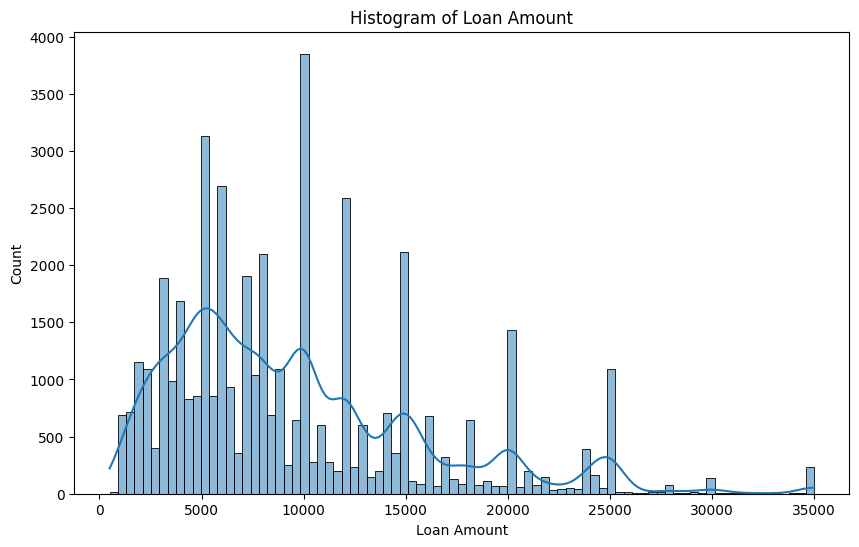

In [106]:
#chick for outliers

Q1 = data['loan_amnt'].quantile(0.25)
Q3 = data['loan_amnt'].quantile(0.75)   
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['loan_amnt'] < lower_bound) | (data['loan_amnt'] > upper_bound)]
print(f"Number of outliers in 'loan_amnt': {outliers.shape[0]}")

# Visualize outliers using a box plot
plt.figure(figsize=(10, 6))     
sns.histplot(x=data['loan_amnt'], kde=True)
plt.title('Histogram of Loan Amount')
plt.xlabel('Loan Amount')   
plt.show()



Number of outliers in 'loan_amnt' after clipping: 0


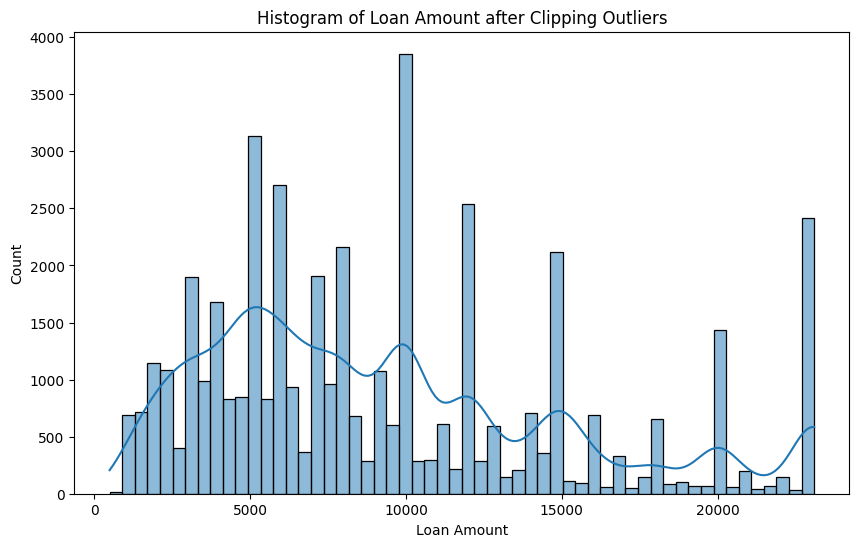

In [107]:
# after clipping for outliers 
data['loan_amnt'] = data['loan_amnt'].clip(lower_bound, upper_bound)
print(f"Number of outliers in 'loan_amnt' after clipping: {data[(data['loan_amnt'] < lower_bound) | (data['loan_amnt'] > upper_bound)].shape[0]}")
plt.figure(figsize=(10, 6))
sns.histplot(x=data['loan_amnt'], kde=True) 
plt.title('Histogram of Loan Amount after Clipping Outliers')
plt.xlabel('Loan Amount')
plt.show()




In [108]:
# اختيار الأعمدة العددية فقط

# فحص skewness قبل التحويل
print("Skewness BEFORE transformation:\n")

for col in numerical_data:
    if data[col].nunique() > 2:   # تجاهل الأعمدة الثنائية
        print(col, ":", data[col].skew())

print("\nApplying log transformation...\n")

# معالجة skewness
for col in numerical_data:

    # تجاهل الأعمدة الثنائية
    if data[col].nunique() <= 2:
        continue

    skew_val = data[col].skew()

    # تطبيق log فقط إذا كان skew كبير
    if abs(skew_val) > 1:

        # إزالة القيم المفقودة قبل الفحص
        if (data[col].dropna() >= 0).all():

            data[col] = np.log1p(data[col])

            print(col, "transformed")
            print("New skew:", data[col].skew())
            print("-------------------")

Skewness BEFORE transformation:

person_age : 2.5481540050382425
person_income : 34.137583132969915
person_emp_exp : 2.5949173726318255
loan_amnt : 0.8133880428310855
loan_int_rate : 0.21378407238735642
loan_percent_income : 1.034512151182724
cb_person_cred_hist_length : 1.6317199538415355
credit_score : -0.6102608322577946

Applying log transformation...

person_age transformed
New skew: 1.2202035131844058
-------------------
person_income transformed
New skew: 0.22401825307468148
-------------------
person_emp_exp transformed
New skew: -0.12299024997657408
-------------------
loan_percent_income transformed
New skew: 0.8293008832080409
-------------------
cb_person_cred_hist_length transformed
New skew: 0.4426559952950037
-------------------


# Visualization

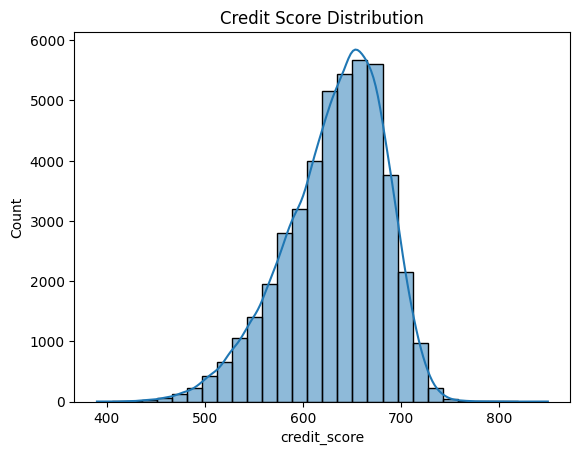

In [109]:
sns.histplot(data["credit_score"], bins=30, kde=True)
plt.title("Credit Score Distribution")
plt.show()

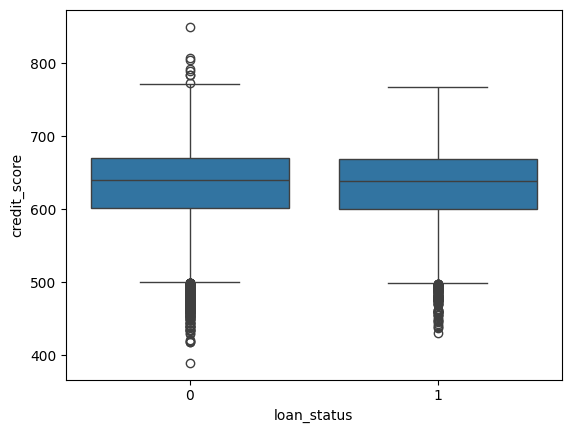

In [110]:
sns.boxplot(x="loan_status", y="credit_score", data=data)
plt.show()

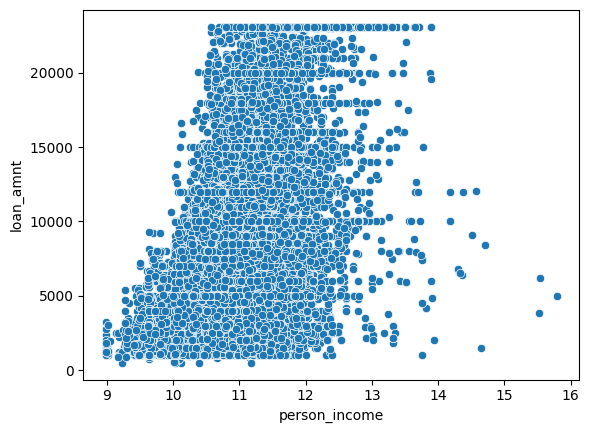

In [111]:
sns.scatterplot(x="person_income", y="loan_amnt", data=data)
plt.show()

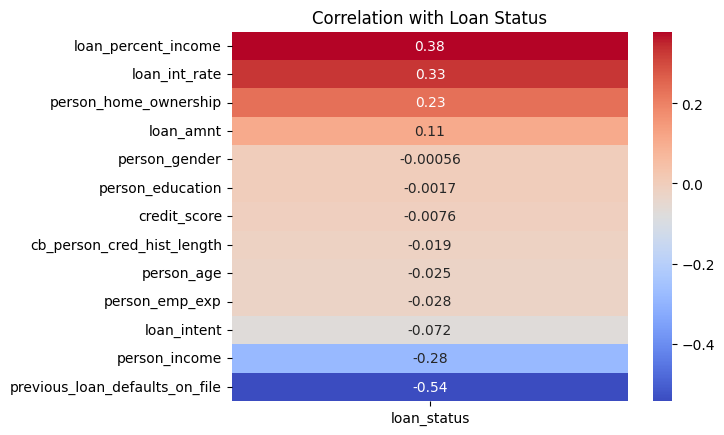

In [112]:

# Correlation Series
corr = data.corr()['loan_status'].drop('loan_status').sort_values(ascending=False)

# Convert to DataFrame for heatmap
corr_df = corr.to_frame()  # shape (n_features, 1)

sns.heatmap(corr_df, annot=True, cmap='coolwarm')
plt.title('Correlation with Loan Status')
plt.show()

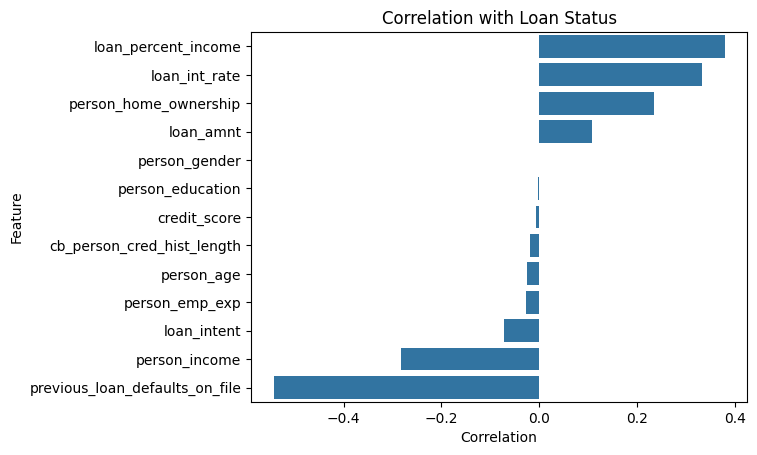

In [113]:
sns.barplot(x=corr.values, y=corr.index)
plt.title('Correlation with Loan Status')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.show()

# Spliting data

In [114]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


X = data.drop("loan_status", axis=1)
y = data["loan_status"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler())
])

# Logistic Regression

In [115]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [116]:
from sklearn.model_selection import GridSearchCV

# إنشاء Logistic Regression
log_regression = LogisticRegression(max_iter=2000)

param_grid = [
    {'C': [0.1, 1, 10],
     'penalty': ['l1'],
     'solver': ['liblinear']},  # أسرع للـ L1
    {'C': [0.1, 1, 10],
     'penalty': ['l2'],
     'solver': ['liblinear','lbfgs']}  # أسرع للـ L2
]

# GridSearchCV
grid = GridSearchCV(log_regression, param_grid, scoring='accuracy', cv=5)
grid.fit(X_train, y_train)

# أفضل hyperparameters
print("Best Hyperparameters:", grid.best_params_)

# التنبؤ على بيانات الاختبار
y_pred = grid.predict(X_test)

Best Hyperparameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


In [117]:

# تقييم النموذج
print("Logistic Regression - Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Logistic Regression - Accuracy: 0.8971111111111111
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      7000
           1       0.77      0.76      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000

Confusion Matrix:
 [[6555  445]
 [ 481 1519]]


Confusion Matrix:
[[6555  445]
 [ 481 1519]]


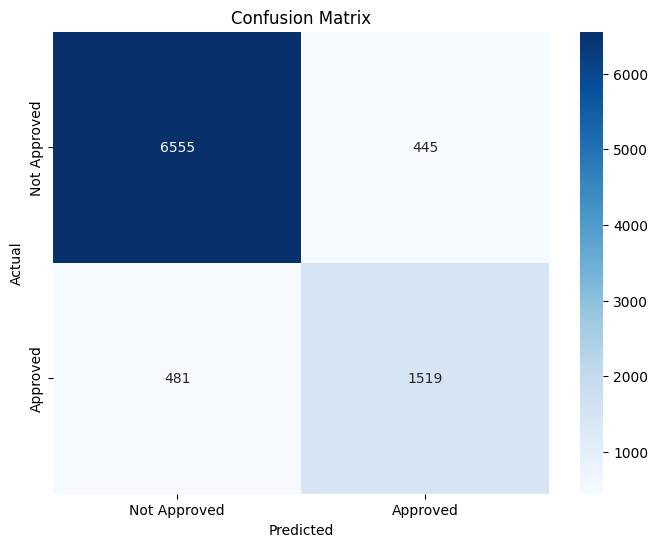

In [118]:
# حساب مصفوفة الارتباك
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# رسم مصفوفة الارتباك باستخدام seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Approved', 'Approved'], yticklabels=['Not Approved', 'Approved'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# K-Nearest Neighbors (K-NN) 

In [119]:
# إنشاء النموذج
model = KNeighborsClassifier(n_neighbors=10)
model.fit(X_train, y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [120]:
# التنبؤ
y_pred = model.predict(X_test)

In [121]:
# تقييم النموذج
accuracy = accuracy_score(y_test, y_pred)
print(f'K-Nearest Neighbors (K-NN) - Accuracy: {accuracy}')
# تقرير التصنيف
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

K-Nearest Neighbors (K-NN) - Accuracy: 0.8997777777777778
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      7000
           1       0.83      0.69      0.75      2000

    accuracy                           0.90      9000
   macro avg       0.87      0.82      0.85      9000
weighted avg       0.90      0.90      0.90      9000



Confusion Matrix:
[[6723  277]
 [ 625 1375]]


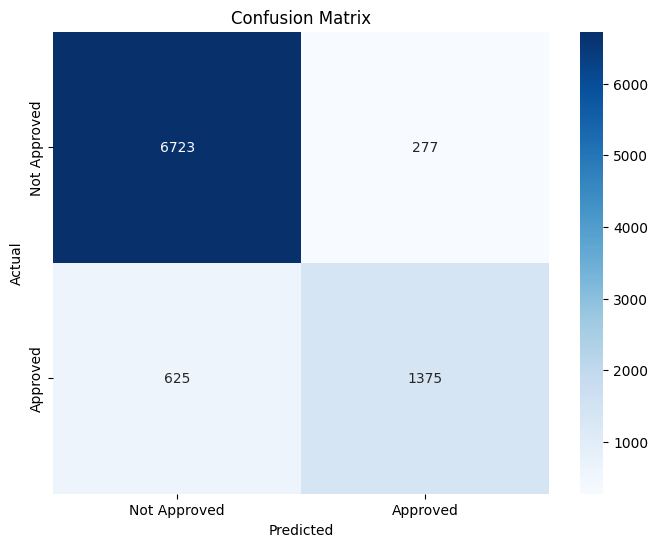

In [122]:
# حساب مصفوفة الارتباك
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# رسم مصفوفة الارتباك باستخدام seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Approved', 'Approved'], yticklabels=['Not Approved', 'Approved'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Support Vector Machine (SVM)

In [123]:
# Train SVM Classifier 
SVM_classifier=SVC(kernel="linear", random_state=42)
SVM_classifier.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [124]:
y_pred_SVM=SVM_classifier.predict(X_test)

In [125]:
#evaluation

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_SVM))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_SVM)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred_SVM))


Accuracy: 0.8968888888888888
Confusion Matrix:
 [[6556  444]
 [ 484 1516]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      7000
           1       0.77      0.76      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000



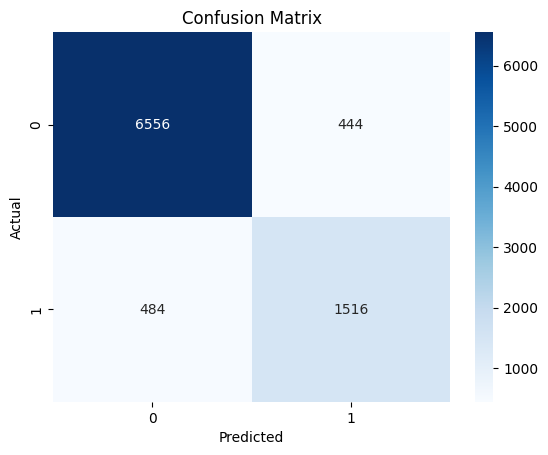

In [126]:
# Plot Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# Kernal_Support Vector Machine(SVM)

In [127]:
# 7. Train Kernel SVM Model
kernel_svm_classifier =SVC(kernel='rbf', random_state=42)
kernel_svm_classifier.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [128]:
# 8. Make Predictions
y_pred_kernel = kernel_svm_classifier.predict(X_test)

In [129]:
# 9. Evaluate the Model

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_kernel))

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred_kernel))


Accuracy: 0.9104444444444444
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.94      7000
           1       0.83      0.75      0.79      2000

    accuracy                           0.91      9000
   macro avg       0.88      0.85      0.87      9000
weighted avg       0.91      0.91      0.91      9000



Confusion Matrix:
 [[6689  311]
 [ 495 1505]]


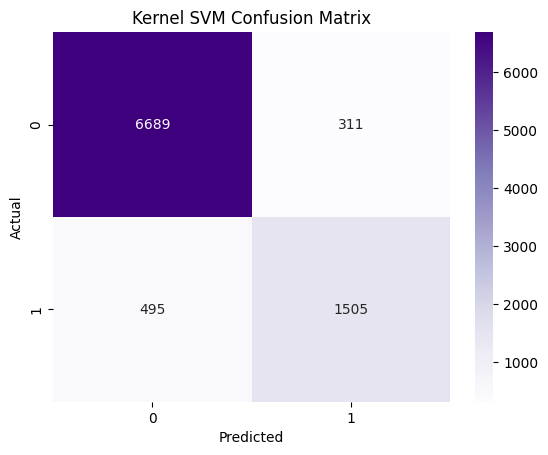

In [130]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_kernel)
print("Confusion Matrix:\n", cm)

# 10. Plot Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Kernel SVM Confusion Matrix')
plt.show()

# Naive Bayes

In [131]:
#Create Naive Bayes Model
model = GaussianNB()

In [132]:
#Train Model
model.fit(X_train, y_train)


,priors,None
,var_smoothing,1e-09


In [133]:
# Make Predictions
y_pred = model.predict(X_test)

In [134]:
# Evaluate Model

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy")
print(f"Accuracy: {accuracy:.4f}")

print("\n" + "-"*50)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix")
print(cm)

print("\n" + "-"*50)

# Classification Report
cr = classification_report(y_test, y_pred)
print("Classification Report")
print(cr)


Model Accuracy
Accuracy: 0.7328

--------------------------------------------------
Confusion Matrix
[[4595 2405]
 [   0 2000]]

--------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0       1.00      0.66      0.79      7000
           1       0.45      1.00      0.62      2000

    accuracy                           0.73      9000
   macro avg       0.73      0.83      0.71      9000
weighted avg       0.88      0.73      0.76      9000



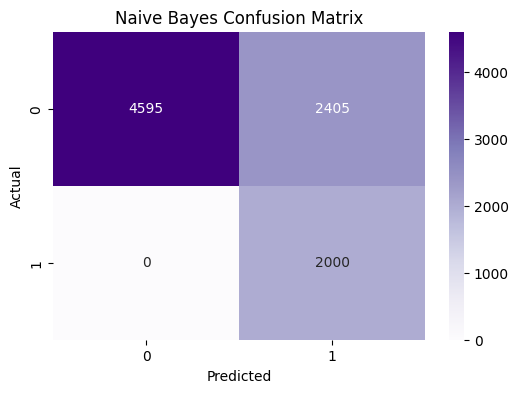

In [135]:
# Plot Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()


# Decision_Tree_Classification

In [136]:
# 7. Train Decision Tree Classifier Model
dt_classifier = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_classifier.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [137]:
# 8. Make Predictions
y_pred_dt = dt_classifier.predict(X_test)

In [138]:
# 9. Evaluate the Model

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred_dt))


Accuracy: 0.9012222222222223
Confusion Matrix:
 [[6548  452]
 [ 437 1563]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94      7000
           1       0.78      0.78      0.78      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.86      0.86      9000
weighted avg       0.90      0.90      0.90      9000



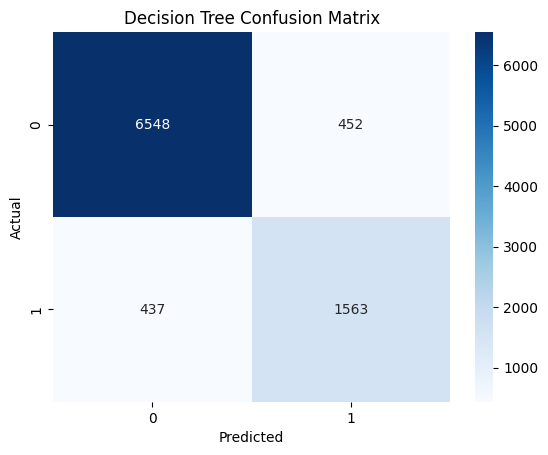

In [139]:
# 10. Plot Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

# Random_Forest_Classification

In [140]:
# 7. Train Random Forest Classifier Model
rf_classifier = RandomForestClassifier(random_state=42, n_estimators=200, criterion='gini', max_depth=None)
rf_classifier.fit(X_train, y_train)
# 8. Make Predictions
y_pred_rf = rf_classifier.predict(X_test)


In [141]:
# 9. Evaluate the Model
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.9286666666666666
Confusion Matrix:
 [[6811  189]
 [ 453 1547]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95      7000
           1       0.89      0.77      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.91      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



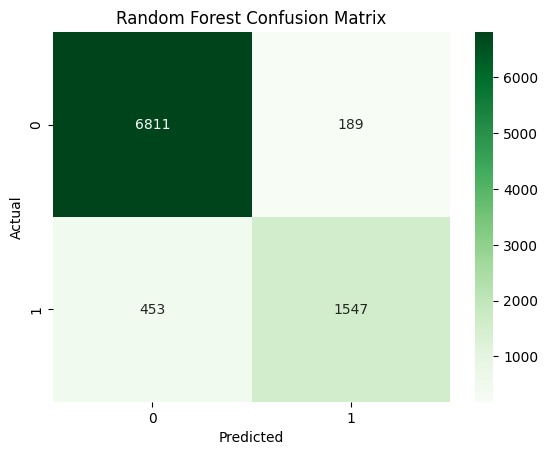

In [142]:
# 10. Plot Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()


# Compresion between all models

Model Accuracies:
Logistic Regression: 0.8971
K-NN: 0.7328
SVM: 0.8969
Kernel SVM: 0.9104
Naive Bayes: 0.7328
Decision Tree: 0.9012
Random Forest: 0.9287


C:\Users\DELL\AppData\Local\Temp\ipykernel_19008\3219948065.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


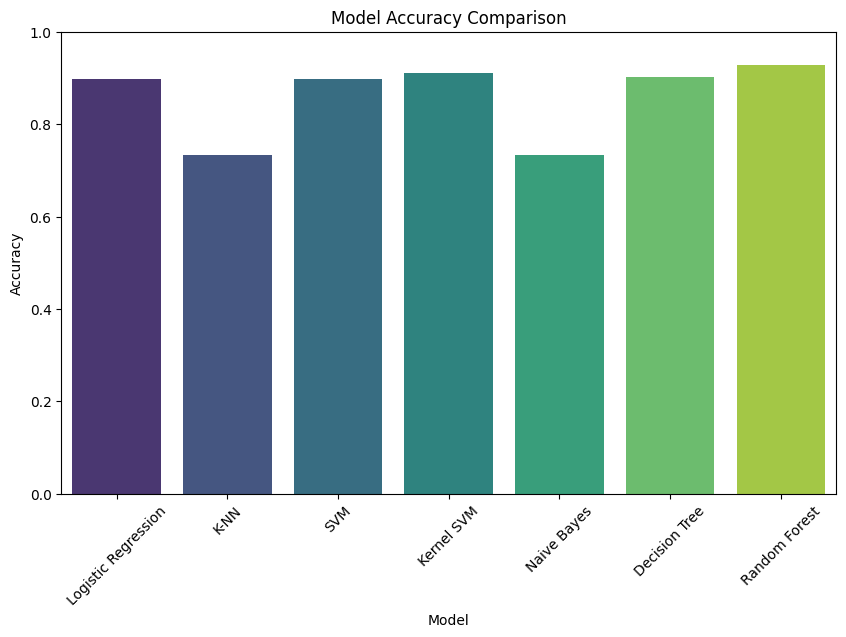

In [143]:
# compare the models
models = ['Logistic Regression', 'K-NN', 'SVM', 'Kernel SVM', 'Naive Bayes', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, grid.predict(X_test)),
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_SVM),
    accuracy_score(y_test, y_pred_kernel),
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]
print("Model Accuracies:")
for model, acc in zip(models, accuracies):
    print(f"{model}: {acc:.4f}")
    
       
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()


In [144]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42, n_estimators=200))
])

pipeline.fit(X_train, y_train)

# حفظ الـ pipeline كله دفعة واحدة
joblib.dump(pipeline, 'best_model.pkl')

['best_model.pkl']